# Tamil Vowel Image Classification – CNN

### Objective
To design and train a Convolutional Neural Network (CNN) model for accurate classification of Tamil vowel characters from image data, ensuring optimal performance through validation-based model selection and early stopping techniques.

#### Import Required Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models # used to build CNN architecture.
from tensorflow.keras.preprocessing import image # for loading and preprocessing test images.
import os # To handle directory operations
import numpy as np
import matplotlib.pyplot as plt

#### Upload Dataset - its Zip file

In [ ]:
# it Allows manual dataset upload from local system
from google.colab import files
uploaded = files.upload()

Saving uiyer_ezhuthukals.zip to uiyer_ezhuthukals.zip


#### Unzip Dataset

In [ ]:
!unzip -q uiyer_ezhuthukals.zip #-q - quiet mode (no verbose output- no progress, warnings, download details, logs)

replace uiyer_ezhuthukal/அ/அ (1).png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


#### Verify Extracted Dataset

In [ ]:
data_dir = "uiyer_ezhuthukal"
print(f"Extracted folders: {os.listdir(data_dir)}")

Extracted folders: ['ஈ', 'அ', 'ஐ', 'இ', 'ஏ', 'ஓ', 'எ', 'ஆ', 'உ', 'ஒ', 'ஔ', 'ஊ']


#### Define Image Parameters

In [ ]:
data_dir = "uiyer_ezhuthukal"
batch_size = 32 # number of images per training step - it balanced memory & speed.
img_height = 128
img_width = 128

#### Create Training & Validation Datasets

In [ ]:
# Automatically: Loads images and Labels them based on folder names

train_ds = tf.keras.utils.preprocessing.image_dataset_from_directory(data_dir, validation_split= 0.2, subset= "training", seed = 123, image_size=(img_height, img_width), batch_size = batch_size)
                                                                                                                        # seed = 123 - ensures reproducibility
val_ds = tf.keras.utils.preprocessing.image_dataset_from_directory(data_dir, validation_split= 0.2, subset = "validation", seed = 123,  image_size = (img_height, img_width), batch_size= batch_size)
print("Print class name found": Train_ds.class_names)

Found 8000 files belonging to 12 classes.
Using 6400 files for training.
Found 8000 files belonging to 12 classes.
Using 1600 files for validation.


#### Optimize Data Pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE) # cache() - stores data in memory, shuffle(1000) - avoids model bias
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE) # prefetch() - loads next batch while training

#### Build CNN Architecture

In [ ]:
# Sequential model is used when data flows linearly from "Output of one layer --> input of next layer"
                      # Converts pixel values 0–255 --> 0–1.   (img_h,img_w,channels = RGB)
model = models.Sequential([layers.Rescaling(1./255, input_shape= (128, 128, 3)),

                           # First Convolution Block    Adds non-linearity (Prevents vanishing gradients)
                           layers.Conv2D(32, (3,3), activation= 'relu'), # 32 filter and 3 x 3 is filter size(small patches) to - learn 32 different visual features based 3(h-pixel) x 3(w-pixel) one by one
                           layers.MaxPooling2D((2,2)), #Pooling reduces image size--> it check the 2(h-pixel) x 2(w-pixel) = 4 pixel and it keep largest value then it moves to the next 2 × 2 region
                           # Second Convolution Block
                           layers.Conv2D(64, (3,3), activation='relu'), layers.MaxPooling2D((2,2)),
                           # Third Convolution Block
                           layers.Conv2D(128, (3,3), activation= 'relu'), layers.MaxPooling2D((2,2)),
                           # Flatten and Dense Layers
                           layers.Flatten(), layers.Dense(128, activation='relu'), #dense layer can't understand 3D-(h,w, channels) so it converted into 1D
                           layers.Dropout(0.5), # Dropout(0.5) - prevents overfitting
                           # Output Layer
                           layers.Dense(12, activation= 'softmax') #Dense layer combines all these features and decides output
                           ])

#### Compile the Model

In [ ]:
model.compile(optimizer = 'adam', loss= 'sparse_categorical_crossentropy', metrics= ['accuracy'])

####  Model summary - to view the architecture

In [ ]:
# It Displays: Layer types, Output shapes, Number of parameters
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,188 (12.61 MB)

 Trainable params: 3,306,188 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

#### Callbacks

In [ ]:
# EarlyStopping and ModelCheckpoint callbacks to prevent overfitting and automatically persist the best-performing CNN model based on validation loss
early_stop = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True) # early_stop - Stops training if it doesn’t improve for 5 epochs and Restores the best weights automatically

Checkpoint = tf.keras.callbacks.ModelCheckpoint("best_tamil_model.keras", save_best_only = True) # Checkpoint - Saves the model only when validation loss improves

#### Train the Model

In [ ]:
# started with 10 epochs - for better accuracy i set 25 epochs
history = model.fit(train_ds, validation_data = val_ds, epochs = 25, callbacks = [early_stop,Checkpoint] )

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.1805 - loss: 2.2949 - val_accuracy: 0.4013 - val_loss: 1.7791
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4459 - loss: 1.5579 - val_accuracy: 0.6919 - val_loss: 0.9472
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6020 - loss: 1.0974 - val_accuracy: 0.7581 - val_loss: 0.7233
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7041 - loss: 0.8146 - val_accuracy: 0.8138 - val_loss: 0.5489
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7575 - loss: 0.6612 - val_accuracy: 0.8238 - val_loss: 0.4921
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8050 - loss: 0.5356 - val_accuracy: 0.8481 - val_loss: 0.4408
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8227 - loss: 0.4803 - val_accuracy: 0.8806 - val_loss: 0.3511
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8489 - loss: 0.4044 - val_acc

#### Load the Best Trained CNN Model

In [ ]:
best_model = tf.keras.models.load_model("best_tamil_model.keras")

#### Plot Training vs Validation Accuracy

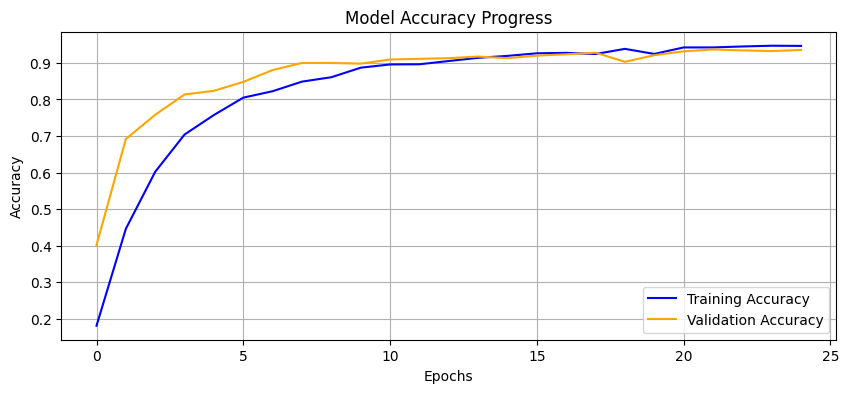

In [ ]:
# Visualizes overfitting or underfitting
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
# Gap between curves indicates generalization quality

#### Predict on New Image

In [ ]:

test_image_path = "/content/aa.png"
class_names = sorted(os.listdir("uiyer_ezhuthukal"))

# Load and preprocess the image exactly like the training data
img = image.load_img(test_image_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Create a batch of 1

# Predict the class
predictions = best_model.predict(img_array)
score = tf.nn.softmax(predictions[0])
predicted_class_idx = np.argmax(score)

# Get the Tamil character label

print(f"Predicted Character: {class_names[predicted_class_idx]}")
print(f"Confidence Score: {100 * np.max(score):.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Predicted Character: ஆ
Confidence Score: 19.80%
